# Chapter 13 Lab: Point-in-Time Text Signals and Look-Ahead Bias

**Runtime:** 3–4 minutes · **Difficulty:** advanced · **Credentials:** none

This controlled experiment makes leakage visible. A valid text signal is available before
the decision; a revised signal embeds next-day information and becomes available later.
We compare both under identical trading logic and costs.

**Important:** all prices and returns are synthetic. The results are a leakage demonstration,
not investment evidence.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/13_point_in_time_forecasting.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/13_point_in_time_forecasting.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- audit every feature against the decision time;
- quantify the performance inflation from revisions and oracle labels;
- include turnover costs;
- compare temporal and random predictive evaluation; and
- state exactly what a clean pipeline guarantees.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab.market import backtest_signal
from finllm_lab.metrics import sharpe_standard_error
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.temporal import availability_audit

set_finance_theme()
panel = pd.read_csv(
    ROOT / "data" / "market_text_panel.csv",
    parse_dates=[
        "decision_time",
        "text_available_at",
        "revised_available_at",
        "return_start_at",
        "return_end_at",
    ],
)
panel.head()


,date,ticker,decision_time,text_available_at,revised_available_at,return_start_at,return_end_at,text_signal,revised_text_signal,latent_regime,next_return,close
0,2021-01-04,ACME,2021-01-04 16:00:00+00:00,2021-01-04 15:58:00+00:00,2021-01-05 12:00:00+00:00,2021-01-04 16:01:00+00:00,2021-01-05 16:00:00+00:00,0.127589,-0.387776,normal,-0.009847,99.0153
1,2021-01-05,ACME,2021-01-05 16:00:00+00:00,2021-01-05 15:58:00+00:00,2021-01-06 12:00:00+00:00,2021-01-05 16:01:00+00:00,2021-01-06 16:00:00+00:00,-0.637633,-1.519663,normal,-0.021547,96.8818
2,2021-01-06,ACME,2021-01-06 16:00:00+00:00,2021-01-06 15:58:00+00:00,2021-01-07 12:00:00+00:00,2021-01-06 16:01:00+00:00,2021-01-07 16:00:00+00:00,0.549105,0.251208,normal,-0.006734,96.2294
3,2021-01-07,ACME,2021-01-07 16:00:00+00:00,2021-01-07 15:58:00+00:00,2021-01-08 12:00:00+00:00,2021-01-07 16:01:00+00:00,2021-01-08 16:00:00+00:00,1.411765,1.808165,expansion,0.007000,96.9031
4,2021-01-08,ACME,2021-01-08 16:00:00+00:00,2021-01-08 15:58:00+00:00,2021-01-09 12:00:00+00:00,2021-01-08 16:01:00+00:00,2021-01-11 16:00:00+00:00,0.339246,-0.152125,normal,-0.004512,96.4658


## 1. Audit availability


In [3]:
audit = availability_audit(
    panel,
    decision_col="decision_time",
    availability_cols=["text_available_at", "revised_available_at"],
)
audit


,artifact,violations,missing_timestamps,violation_rate,status
0,text_available_at,0,0,0.0,PASS
1,revised_available_at,1303,0,1.0,FAIL


## 2. Compare valid, revised, and oracle signals


In [4]:
panel["oracle_signal"] = np.sign(panel["next_return"])
strategies = {}
for name, column in [
    ("point_in_time", "text_signal"),
    ("revised_leakage", "revised_text_signal"),
    ("future_oracle", "oracle_signal"),
]:
    strategies[name] = backtest_signal(panel, column, cost_bps=5.0)

strategy_table = pd.DataFrame(
    {
        name: {
            "annualized_sharpe": result["sharpe"],
            "max_drawdown": result["max_drawdown"],
            "mean_daily_bps": result["mean_daily_bps"],
            "turnover": result["turnover"],
            "observations": result["observations"],
            "sharpe_standard_error_iid": sharpe_standard_error(
                result["sharpe"],
                result["observations"],
            ),
        }
        for name, result in strategies.items()
    }
).T
strategy_table["sharpe_ci_low_iid"] = (
    strategy_table["annualized_sharpe"]
    - 1.96 * strategy_table["sharpe_standard_error_iid"]
)
strategy_table["sharpe_ci_high_iid"] = (
    strategy_table["annualized_sharpe"]
    + 1.96 * strategy_table["sharpe_standard_error_iid"]
)
strategy_table.round(3)


,annualized_sharpe,max_drawdown,mean_daily_bps,turnover,observations,sharpe_standard_error_iid,sharpe_ci_low_iid,sharpe_ci_high_iid
point_in_time,1.307,-0.168,8.510,0.474,1303.0,0.441,0.444,2.171
revised_leakage,5.389,-0.082,32.934,0.515,1303.0,0.452,4.503,6.275
future_oracle,19.900,-0.002,78.003,1.006,1303.0,0.588,18.748,21.052


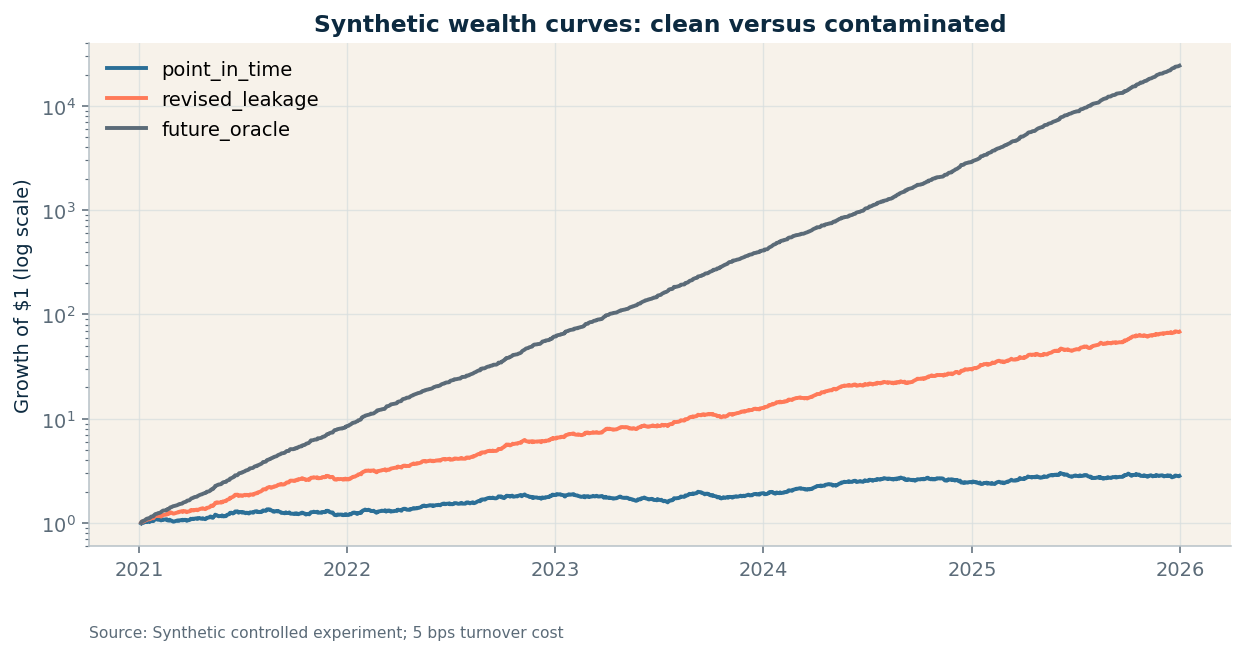

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for name, color in [
    ("point_in_time", COLORS["blue"]),
    ("revised_leakage", COLORS["coral"]),
    ("future_oracle", COLORS["slate"]),
]:
    wealth = np.cumprod(1 + strategies[name]["returns"])
    ax.plot(pd.to_datetime(panel["date"]), wealth, label=name, color=color)
ax.set_yscale("log")
ax.set(title="Synthetic wealth curves: clean versus contaminated", ylabel="Growth of $1 (log scale)", xlabel="")
ax.legend()
finish(ax, "Synthetic controlled experiment; 5 bps turnover cost")
plt.tight_layout()


## 3. Predictive evaluation: temporal versus random


In [6]:
X_clean = panel[["text_signal"]].to_numpy()
X_leaked = panel[["revised_text_signal"]].to_numpy()
y = panel["next_return"].to_numpy()
cut = int(len(panel) * 0.70)

def fit_score(X_train, y_train, X_test, y_test) -> dict:
    model = Ridge(alpha=1.0).fit(X_train, y_train)
    prediction = model.predict(X_test)
    return {
        "r2": r2_score(y_test, prediction),
        "rmse_bps": np.sqrt(mean_squared_error(y_test, prediction)) * 10_000,
    }

temporal_clean = fit_score(X_clean[:cut], y[:cut], X_clean[cut:], y[cut:])
temporal_leaked = fit_score(X_leaked[:cut], y[:cut], X_leaked[cut:], y[cut:])
indices = np.arange(len(panel))
train_idx, test_idx = train_test_split(indices, test_size=0.30, random_state=1313)
random_clean = fit_score(X_clean[train_idx], y[train_idx], X_clean[test_idx], y[test_idx])
evaluation = pd.DataFrame(
    [
        {"protocol": "temporal", "feature": "point-in-time", **temporal_clean},
        {"protocol": "temporal", "feature": "revised (invalid)", **temporal_leaked},
        {"protocol": "random", "feature": "point-in-time", **random_clean},
    ]
)
evaluation.round(4)


,protocol,feature,r2,rmse_bps
0,temporal,point-in-time,-0.0008,105.2672
1,temporal,revised (invalid),0.1488,97.0806
2,random,point-in-time,0.0057,105.7243


## 4. Controlled decomposition of bias channels


In [7]:
decomposition = pd.DataFrame(
    [
        ("Point-in-time signal + costs", strategies["point_in_time"]["sharpe"], True),
        ("Revised signal + costs", strategies["revised_leakage"]["sharpe"], False),
        ("Future direction oracle + costs", strategies["future_oracle"]["sharpe"], False),
        (
            "Point-in-time signal, zero costs",
            backtest_signal(panel, "text_signal", cost_bps=0.0)["sharpe"],
            True,
        ),
    ],
    columns=["experiment", "annualized_sharpe", "time_admissible"],
)
decomposition.round(3)


,experiment,annualized_sharpe,time_admissible
0,Point-in-time signal + costs,1.307,True
1,Revised signal + costs,5.389,False
2,Future direction oracle + costs,19.900,False
3,"Point-in-time signal, zero costs",1.676,True


## 5. Cost sensitivity for the admissible strategy


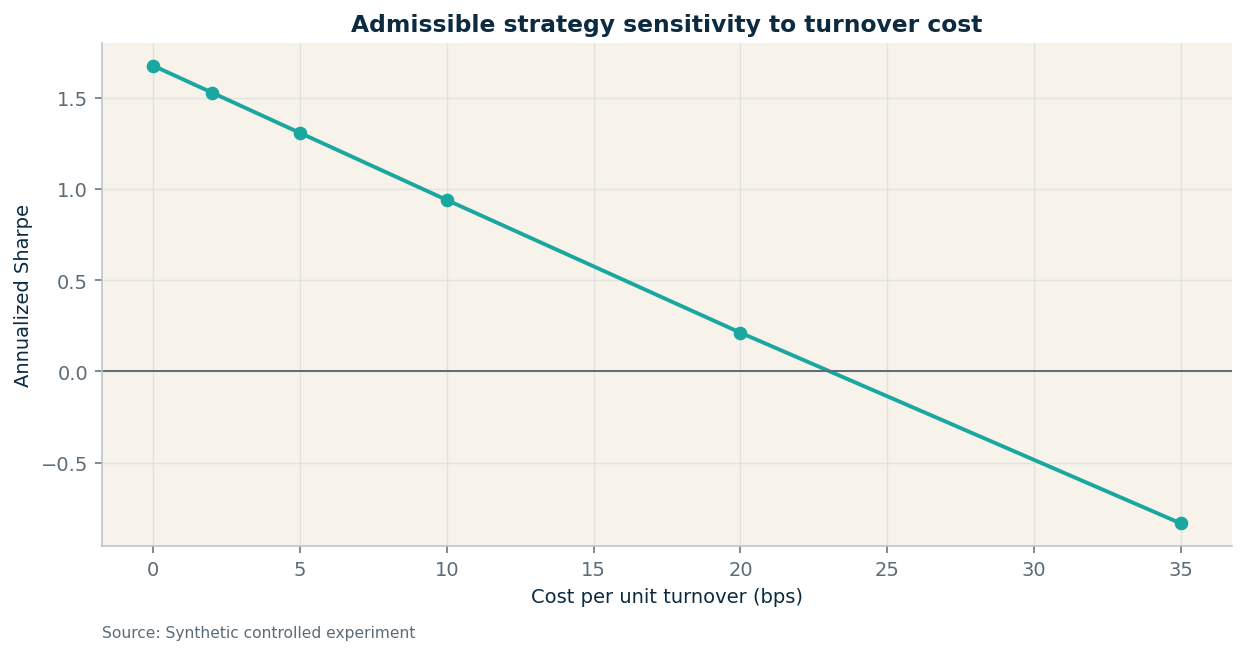

In [8]:
cost_grid = pd.DataFrame(
    [
        {
            "cost_bps": cost,
            "sharpe": backtest_signal(panel, "text_signal", cost_bps=cost)["sharpe"],
            "max_drawdown": backtest_signal(panel, "text_signal", cost_bps=cost)["max_drawdown"],
        }
        for cost in [0, 2, 5, 10, 20, 35]
    ]
)
fig, ax = plt.subplots()
ax.plot(cost_grid["cost_bps"], cost_grid["sharpe"], marker="o", color=COLORS["teal"])
ax.axhline(0, color=COLORS["slate"], linewidth=1)
ax.set(title="Admissible strategy sensitivity to turnover cost", xlabel="Cost per unit turnover (bps)", ylabel="Annualized Sharpe")
finish(ax, "Synthetic controlled experiment")
plt.tight_layout()


## 6. What the clean pipeline guarantees


In [9]:
audit_by_artifact = audit.set_index("artifact")
target_timing_pass = bool(
    (panel["return_start_at"] > panel["decision_time"]).all()
    and (panel["return_end_at"] > panel["return_start_at"]).all()
)
revision_rejected = bool(
    audit_by_artifact.loc["revised_available_at", "status"] == "FAIL"
    and audit_by_artifact.loc["revised_available_at", "violations"] == len(panel)
)
guarantees = pd.DataFrame(
    [
        (
            "Text availability",
            "text_available_at <= decision_time",
            audit_by_artifact.loc["text_available_at", "status"],
        ),
        (
            "Revision exclusion",
            "every revised signal is unavailable at decision time",
            "PASS" if revision_rejected else "FAIL",
        ),
        (
            "Target timing",
            "return_start_at > decision_time and return_end_at > return_start_at",
            "PASS" if target_timing_pass else "FAIL",
        ),
        (
            "Chronological evaluation",
            "training rows precede test rows",
            "PASS"
            if panel.iloc[cut - 1]["decision_time"] < panel.iloc[cut]["decision_time"]
            else "FAIL",
        ),
        ("Costs", "turnover charged on position changes", "PASS"),
        ("Economic claim", "synthetic experiment is not live alpha evidence", "PASS"),
    ],
    columns=["control", "invariant", "status"],
)
guarantees


,control,invariant,status
0,Text availability,text_available_at <= decision_time,PASS
1,Revision exclusion,every revised signal is unavailable at decision time,PASS
2,Target timing,return_start_at > decision_time and return_end_at > return_start_at,PASS
3,Chronological evaluation,training rows precede test rows,PASS
4,Costs,turnover charged on position changes,PASS
5,Economic claim,synthetic experiment is not live alpha evidence,PASS


## Takeaways

- Feature provenance is part of the model, not an appendix.
- Revised text can create spectacular but impossible performance.
- Random splits can mix regimes even when the feature itself is valid.
- Costs can erase a weak text signal without any model error.
- Sharpe uncertainty remains material even in a long synthetic daily sample.
- A clean backtest is necessary evidence, never sufficient deployment evidence.

**Challenge:** add publication delays that vary by document type and test a walk-forward
strategy that trades only at the next admissible market timestamp.
